# Configuration

In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

# Functions

In [2]:
def read_files(dataset: str, split: str, directory: str = ".") -> pd.DataFrame:
    prefix = f"extractive_{dataset}_{split}_"
    files = [
        filename
        for filename in os.listdir(directory)
        if filename.startswith(prefix) and filename.endswith(".json")
    ]

    evals = []
    for filename in files:
        base = filename.replace(prefix, "").replace(".json", "")
        model, count_str = base.rsplit("_", 1)
        count = int(count_str)

        path = os.path.join(directory, filename)
        with open(path, "r") as f:
            metrics = json.load(f)

        row = {"file": filename, "model": model, "count": count}
        row.update(metrics)
        evals.append(row)

    return pd.DataFrame(evals)


def normalize_scores(df: pd.DataFrame, exclude: list = None) -> pd.DataFrame:
    if exclude is None:
        exclude = ["file", "model", "count"]

    metric_cols = [c for c in df.columns if c not in exclude]
    df_norm = df.copy()

    for col in metric_cols:
        min_val, max_val = df[col].min(), df[col].max()
        if max_val > min_val:
            df_norm[col] = (df[col] - min_val) / (max_val - min_val)
        else:
            df_norm[col] = 0.5

    df_norm["score"] = df_norm[metric_cols].mean(axis=1)

    return df_norm


def find_best(df: pd.DataFrame) -> pd.Series:
    idx = df["score"].idxmax()
    return df.loc[idx, ["file", "model", "count", "score"]]


def plot_performance(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df.sort_values("count"),
        x="count",
        y="score",
        hue="model",
        marker="o",
    )
    plt.title("Score by Model and Sentence Count")
    plt.xlabel("Number of Sentences")
    plt.ylabel("Score (min-max average)")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


def analyse_results(dataset="elife", split="train"):
    df_raw = read_files(dataset, split)
    df_norm = normalize_scores(df_raw)
    plot_performance(df_norm)

    return find_best(df_norm)


# Analysis

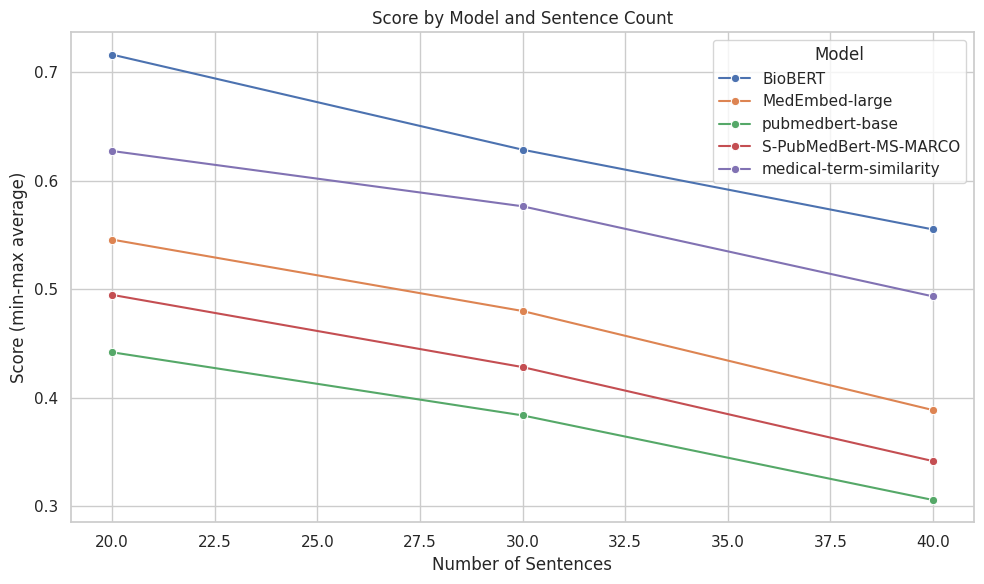

In [3]:
results = analyse_results()